# Evaluación comparativa de variantes de agrupamiento gravitacional sobre Iris (2 características)

Este cuaderno desarrolla un flujo experimental orientado a sustentación académica, usando Iris con etiquetas reales para validación externa.

Algoritmos implementados:
1. Variante clásica gravitacional (dinámica de partículas y fusión)
2. Variante RGC (interacciones aleatorias, enfriamiento y union-find)

## 1. Fundamentación teórica del problema

Sea $X=\{x_i\}_{i=1}^n$, con $x_i \in \mathbb{R}^d$. En clustering gravitacional, cada observación se modela como partícula y la dinámica depende de una fuerza de atracción. De forma general:

$$
\Delta x_i(t) \propto \sum_{j\neq i} F_{ij}(t)
$$

El agrupamiento emerge cuando múltiples trayectorias convergen hacia regiones comunes del espacio de características.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from IPython.display import HTML

SEED = 42
np.random.seed(SEED)

## 2. Diseño de datos y notación experimental

Se seleccionan dos variables de Iris para visualización bidimensional y comparación con etiquetas reales. Tras estandarizar:

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

Esto evita que una característica domine la dinámica gravitacional por diferencias de escala.

In [81]:
iris = load_iris(as_frame=True)
feature_cols = ["sepal length (cm)", "petal length (cm)"]
X_raw = iris.frame[feature_cols].to_numpy()
y_true = iris.target.to_numpy()
target_names = iris.target_names

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Dataset shape: {X.shape}")
print(f"Feature columns: {feature_cols}")
print(f"Classes: {list(target_names)}")

Dataset shape: (150, 2)
Feature columns: ['sepal length (cm)', 'petal length (cm)']
Classes: ['setosa', 'versicolor', 'virginica']


## 3. Inspección inicial de etiquetas reales

Con $y_i \in \{0,1,2\}$ se observa la estructura real de clases. Esta referencia permite evaluar la alineación entre la partición estimada $\hat{y}$ y las etiquetas reales.

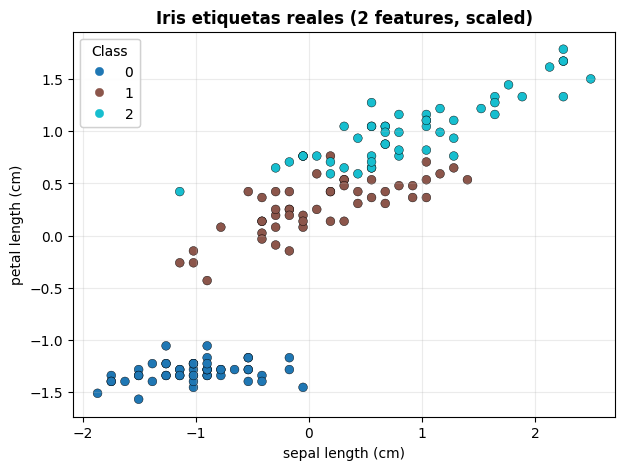

In [82]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=40, edgecolors="k", linewidths=0.3)
ax.set_title("Iris etiquetas reales (2 features, scaled)", fontweight="bold")
ax.set_xlabel(feature_cols[0])
ax.set_ylabel(feature_cols[1])
legend = ax.legend(*scatter.legend_elements(), title="Class", loc="best")
ax.add_artist(legend)
ax.grid(alpha=0.25)
plt.show()

## 4. Formulación de la variante clásica gravitacional (fiel al paper)

Esta formulación sigue de forma intencional el espíritu del esquema clásico de Wright: interacción gravitacional entre todos los pares, actualización directa de posición por aceleración neta y fusión por proximidad.

## 4.1 Desarrollo matemático de la dinámica clásica

La fuerza entre partículas $i,j$ se modela como:

$$
\|F_{ij}\| = G\frac{m_i m_j}{r_{ij}^2+\varepsilon},
$$

Con dirección $\hat{r}_{ij}$ y aceleración neta $a_i = \frac{1}{m_i}\sum_{j\neq i}F_{ij}$. La dinámica discreta implementada es:

$$
x_i^{t+1}=x_i^t + \eta\,a_i^t,
$$

donde $\eta$ es el tamaño de paso. Cuando $r_{ij}<d_{merge}$, las partículas se fusionan mediante centro de masa.

In [83]:
class ClassicalGravitationalClustering:
    """
    Implementacion clasica de clustering gravitacional inspirada en Wright.

    Idea teorica: cada muestra es una particula; la fuerza neta de atraccion
    mueve su posicion y, cuando dos particulas quedan suficientemente cerca,
    se fusionan en su centro de masa.
    """

    def __init__(self, G=0.4, epsilon=1e-2, step_size=0.02, max_iter=250, tol=1e-6, merge_dist=0.2):
        # G: constante gravitacional que escala la magnitud de la interaccion.
        self.G = G
        # epsilon: regularizador numerico para evitar singularidad cuando r_ij -> 0.
        self.epsilon = epsilon
        # step_size (eta): tamano de paso de la actualizacion x^{t+1} = x^t + eta * a^t.
        self.step_size = step_size
        # max_iter: cota superior de iteraciones dinamicas.
        self.max_iter = max_iter
        # tol: umbral de parada por desplazamiento medio pequeno (estado casi estable).
        self.tol = tol
        # merge_dist: distancia umbral para fusionar particulas.
        self.merge_dist = merge_dist

    def fit(self, X, masses=None):
        """
        Ejecuta la dinamica gravitacional y devuelve etiquetas de cluster.

        Parametros
        ----------
        X : array (n, d)
            Datos en espacio d-dimensional.
        masses : array (n,), opcional
            Masas iniciales de las particulas. Si no se pasa, se usan masas unitarias.
        """
        n, d = X.shape
        # Estado dinamico inicial: cada punto inicia en su posicion observada.
        positions = X.copy()

        if masses is None:
            masses = np.ones(n)
        else:
            masses = masses.copy()

        # membership[i] guarda los indices originales que representan la particula i.
        membership = [[i] for i in range(n)]
        # active indica que particulas siguen vivas tras fusiones sucesivas.
        active = np.ones(n, dtype=bool)

        # Historial para analizar convergencia y visualizacion de trayectoria.
        self.history_ = {
            "positions": [positions.copy()],
            "n_particles": [n],
            "displacement": [],
        }

        for _ in range(self.max_iter):
            active_idx = np.where(active)[0]
            if len(active_idx) <= 1:
                # Si queda 0 o 1 particula activa, no hay mas estructura que resolver.
                break

            pos_act = positions[active_idx]
            mass_act = masses[active_idx]

            # diff[i,j] = x_j - x_i; define direccion y distancia relativa entre pares.
            diff = pos_act[np.newaxis, :, :] - pos_act[:, np.newaxis, :]
            dist_sq = np.sum(diff**2, axis=2) + self.epsilon
            dist = np.sqrt(dist_sq)

            # Ley gravitacional discreta: |F_ij| = G * m_i * m_j / (r_ij^2 + epsilon).
            mass_prod = mass_act[:, np.newaxis] * mass_act[np.newaxis, :]
            force_mag = self.G * mass_prod / dist_sq
            direction = diff / (dist[:, :, np.newaxis] + 1e-12)
            force_vec = force_mag[:, :, np.newaxis] * direction
            for dd in range(d):
                # Fuerza propia F_ii = 0 por definicion fisica.
                np.fill_diagonal(force_vec[:, :, dd], 0.0)

            # Aceleracion neta: a_i = (sum_j F_ij) / m_i.
            accel = force_vec.sum(axis=1) / mass_act[:, np.newaxis]

            old_pos = pos_act.copy()
            # Actualizacion clasica de posicion sin terminos de velocidad explicitos.
            pos_act = pos_act + self.step_size * accel
            positions[active_idx] = pos_act

            # Distancias post-actualizacion para aplicar regla de fusion por proximidad.
            dists_after = np.linalg.norm(
                pos_act[:, np.newaxis, :] - pos_act[np.newaxis, :, :],
                axis=2,
            )
            np.fill_diagonal(dists_after, np.inf)

            merged_local = set()
            for i_local in range(len(active_idx)):
                if i_local in merged_local:
                    continue
                for j_local in range(i_local + 1, len(active_idx)):
                    if j_local in merged_local:
                        continue
                    if dists_after[i_local, j_local] < self.merge_dist:
                        i_global = active_idx[i_local]
                        j_global = active_idx[j_local]
                        mi, mj = masses[i_global], masses[j_global]
                        m_tot = mi + mj

                        # Fusion via centro de masa: conserva localizacion ponderada por masa.
                        positions[i_global] = (mi * positions[i_global] + mj * positions[j_global]) / m_tot
                        masses[i_global] = m_tot
                        membership[i_global].extend(membership[j_global])
                        membership[j_global] = []
                        active[j_global] = False
                        merged_local.add(j_local)

            # Criterio de convergencia numerica basado en desplazamiento medio.
            disp = np.sqrt(np.sum((pos_act - old_pos) ** 2, axis=1)).mean()
            self.history_["positions"].append(positions.copy())
            self.history_["n_particles"].append(int(active.sum()))
            self.history_["displacement"].append(float(disp))

            if disp < self.tol:
                break

        # Etiquetado final: cada particula activa representa un cluster.
        labels = np.full(n, -1, dtype=int)
        c = 0
        for i in range(n):
            if active[i] and membership[i]:
                for idx in membership[i]:
                    labels[idx] = c
                c += 1

        self.labels_ = labels
        self.n_clusters_ = c
        return self

## 5. Protocolo de validación y métricas

La validación de desempeño en este estudio se centra en ARI y Silhouette. Además, se reporta `noise_frac` como indicador complementario de cobertura de la partición (proporción de muestras descartadas con etiqueta $-1$).

## 5.1 Métricas de desempeño adoptadas

En este estudio se emplean dos métricas principales y un indicador complementario:

1. **ARI (Adjusted Rand Index)**: mide concordancia entre $y$ y $\hat{y}$ corrigiendo por azar.
$$
\mathrm{ARI} = \frac{\mathrm{RI}-\mathbb{E}[\mathrm{RI}]}{\max(\mathrm{RI})-\mathbb{E}[\mathrm{RI}]}
$$
Rango típico: $[-1,1]$, con valores cercanos a $1$ indicando alta concordancia.

2. **Silhouette**: evalúa cohesión y separación de clusters.
$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}
$$
con $a(i)$ distancia media al propio cluster y $b(i)$ al cluster vecino más cercano. Mayor es mejor.

3. **noise_frac** (indicador complementario): fracción de muestras etiquetadas como ruido ($-1$).
$$
\mathrm{noise\_frac}=\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}\{\hat{y}_i=-1\}
$$
Interpretación: valores altos indican mayor descarte de observaciones por el algoritmo; valores bajos indican mayor cobertura de asignación.

In [84]:
def evaluate_clustering(X, labels, y_true):
    valid = labels >= 0
    n_clusters = len(np.unique(labels[valid])) if valid.any() else 0

    out = {
        "n_clusters": n_clusters,
        "ARI": adjusted_rand_score(y_true, labels),
        "noise_frac": float((~valid).mean()),
    }

    if n_clusters >= 2 and valid.sum() > n_clusters:
        out["Silhouette"] = silhouette_score(X[valid], labels[valid])
    else:
        out["Silhouette"] = np.nan

    return out

classic_space = {
    "G": [0.005, 0.01, 0.02],
    "step_size": [0.002, 0.005, 0.01],
    "merge_dist": [0.02, 0.04, 0.06, 0.08],
    "max_iter": [300, 500],
}

classic_rows = []
classic_best = None

for G in classic_space["G"]:
    for step_size in classic_space["step_size"]:
        for merge_dist in classic_space["merge_dist"]:
            for max_iter in classic_space["max_iter"]:
                model = ClassicalGravitationalClustering(
                    G=G,
                    epsilon=1e-2,
                    step_size=step_size,
                    max_iter=max_iter,
                    merge_dist=merge_dist,
                )
                model.fit(X)
                met = evaluate_clustering(X, model.labels_, y_true)
                row = {
                    "G": G,
                    "step_size": step_size,
                    "merge_dist": merge_dist,
                    "max_iter": max_iter,
                    **met,
                }
                classic_rows.append(row)

                if classic_best is None or row["ARI"] > classic_best["ARI"]:
                    classic_best = {
                        **row,
                        "model": model,
                    }

classic = ClassicalGravitationalClustering(
    G=classic_best["G"],
    epsilon=1e-2,
    step_size=classic_best["step_size"],
    max_iter=classic_best["max_iter"],
    merge_dist=classic_best["merge_dist"],
)
classic.fit(X)
classic_metrics = evaluate_clustering(X, classic.labels_, y_true)

pd.DataFrame(classic_rows).sort_values("ARI", ascending=False).head(10)

,G,step_size,merge_dist,max_iter,n_clusters,ARI,noise_frac,Silhouette
49,0.020,0.002,0.02,500,5,0.543184,0.0,0.379335
19,0.005,0.010,0.04,500,6,0.543030,0.0,0.115265
35,0.010,0.005,0.04,500,6,0.543030,0.0,0.115265
18,0.005,0.010,0.04,300,6,0.543030,0.0,0.115265
34,0.010,0.005,0.04,300,6,0.543030,0.0,0.115265
48,0.020,0.002,0.02,300,6,0.541868,0.0,0.356963
26,0.010,0.002,0.04,300,7,0.537890,0.0,0.301631
28,0.010,0.002,0.06,300,7,0.537890,0.0,0.301631
30,0.010,0.002,0.08,300,7,0.537890,0.0,0.301631
14,0.005,0.005,0.08,300,7,0.537890,0.0,0.301631


## 6. Formulación de la variante RGC

RGC reduce el costo de interacción total usando pares aleatorios, enfriamiento de $G$ y agrupación final con union-find.

## 6.1 Desarrollo matemático de RGC (Randomized Gravitational Clustering)

RGC sustituye interacción total $O(n^2)$ por interacciones aleatorias por pares en cada iteración, aproximando la dinámica con costo cercano a $O(Mn)$.

La actualización simplificada implementada es:

$$
\Delta x \;\propto\; G\,\Delta_{jk}\left(\frac{\hat{d}}{\|\Delta_{jk}\|}\right)^3
$$

donde $\hat{d}$ es una escala típica de vecindad. Además, se aplica enfriamiento:

$$
G_{t+1}= (1-\Delta)G_t
$$

y la conectividad final se obtiene con union-find usando umbral de fusión $\varepsilon$.

In [89]:
class UnionFind:
    """
    Estructura disjoint-set (union-find) para mantener componentes conectados.

    En RGC se usa para consolidar pares cercanos (dist <= eps) en un mismo
    componente, y luego mapear cada componente a una etiqueta de cluster.
    """

    def __init__(self, n):
        # parent[i] = representante actual del nodo i.
        self.parent = np.arange(n)
        # rank aproxima altura del arbol para unir de forma eficiente.
        self.rank = np.zeros(n, dtype=int)

    def find(self, a):
        # Busqueda de representante con compresion de caminos.
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a

    def union(self, a, b):
        # Une componentes por rango para mantener arboles bajos.
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1


class RandomizedGravitationalClustering:
    """
    Implementacion RGC (Randomized Gravitational Clustering).

    Idea teorica: aproximar la dinamica gravitacional total mediante interacciones
    aleatorias por pares, aplicar enfriamiento de G y obtener clusters finales
    por conectividad (union-find) con umbral eps.
    """

    def __init__(
        self,
        G0=0.03,
        cooling=0.02,
        M=120,
        eps_mult=2.5,
        min_cluster_size=3,
        k_hat=5,
        seed=42,
        store_history=False,
    ):
        # G0: constante gravitacional inicial.
        self.G0 = G0
        # cooling (Delta): tasa de enfriamiento, G_{t+1} = (1-Delta) G_t.
        self.cooling = cooling
        # M: numero de iteraciones dinamicas.
        self.M = M
        # eps_mult: factor para definir eps = eps_mult * d_hat.
        self.eps_mult = eps_mult
        # min_cluster_size: tamano minimo para aceptar componente como cluster.
        self.min_cluster_size = min_cluster_size
        # k_hat: vecino usado para estimar escala local d_hat.
        self.k_hat = k_hat
        # seed: control de aleatoriedad en emparejamientos.
        self.seed = seed
        # store_history: guarda trayectoria para simulacion/animacion.
        self.store_history = store_history

    @staticmethod
    def estimate_d_hat(X, k=5):
        # d_hat = mediana de la distancia al k-esimo vecino mas cercano.
        nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
        dists, _ = nn.kneighbors(X)
        return float(np.median(dists[:, k]))

    def fit(self, X):
        """
        Ejecuta RGC y expone resultados en atributos con sufijo _.
        """
        rng = np.random.default_rng(self.seed)
        X_dyn = X.copy().astype(float)
        n = X_dyn.shape[0]
        uf = UnionFind(n)

        d_hat = self.estimate_d_hat(X_dyn, k=self.k_hat)
        eps = self.eps_mult * d_hat
        G = self.G0

        # avg_step registra magnitud promedio del desplazamiento por iteracion.
        avg_step = []
        history = [X_dyn.copy()] if self.store_history else None

        for _ in range(self.M):
            step_total = 0.0
            for j in range(n):
                # Seleccion aleatoria de un par distinto (j, k).
                k = rng.integers(0, n - 1)
                if k >= j:
                    k += 1

                delta = X_dyn[k] - X_dyn[j]
                dist = np.linalg.norm(delta) + 1e-12

                # Actualizacion RGC: Delta x proporcional a G * delta * (d_hat/dist)^3.
                step_vec = G * delta * (d_hat / dist) ** 3
                X_dyn[j] += step_vec
                X_dyn[k] -= step_vec

                step_total += np.linalg.norm(step_vec)

                # Regla de conectividad: unir nodos si la distancia cae bajo eps.
                if dist <= eps:
                    uf.union(j, k)

            avg_step.append(step_total / n)
            # Enfriamiento global de G para estabilizar dinamica.
            G *= (1.0 - self.cooling)
            if self.store_history:
                history.append(X_dyn.copy())

        # Cada raiz de union-find define componente conectada.
        roots = np.array([uf.find(i) for i in range(n)])
        uniq, counts = np.unique(roots, return_counts=True)

        labels = -np.ones(n, dtype=int)
        cid = 0
        for r, c in zip(uniq, counts):
            # Componentes pequenas se marcan como ruido (-1).
            if c >= self.min_cluster_size:
                labels[roots == r] = cid
                cid += 1

        # Atributos finales para consumo en evaluacion y visualizacion.
        self.labels_ = labels
        self.X_final_ = X_dyn
        self.avg_step_ = np.array(avg_step)
        self.info_ = {"d_hat": d_hat, "eps": eps, "final_G": G}
        self.history_ = history

        return self

## 7. Selección de hiperparámetros para RGC

El barrido en $\{G_0,\Delta,M,\varepsilon_{mult},\text{min\_cluster\_size}\}$ permite estudiar el compromiso entre separación y sobre-fusión:

- $G_0$ alto incrementa desplazamiento inicial.
- $\Delta$ alto enfría más rápido (menor exploración tardía).
- $\varepsilon_{mult}$ controla conectividad final en union-find.

El criterio de selección principal es maximizar $\mathrm{ARI}(y,\hat{y})$.

In [90]:
# Barrido de hiperparámetros para obtener una comparación estable en Iris
search_space = {
    "G0": [0.0015, 0.0025, 0.004],
    "cooling": [0.015, 0.03],
    "M": [120, 180],
    "eps_mult": [1.0, 1.3, 1.6],
    "min_cluster_size": [3, 5],
}

best = None
rows = []

for G0 in search_space["G0"]:
    for cooling in search_space["cooling"]:
        for M in search_space["M"]:
            for eps_mult in search_space["eps_mult"]:
                for min_cluster_size in search_space["min_cluster_size"]:
                    candidate = RandomizedGravitationalClustering(
                        G0=G0,
                        cooling=cooling,
                        M=M,
                        eps_mult=eps_mult,
                        min_cluster_size=min_cluster_size,
                        seed=SEED,
                        store_history=False,
                    )
                    candidate.fit(X)
                    met = evaluate_clustering(X, candidate.labels_, y_true)
                    row = {
                        "G0": G0,
                        "cooling": cooling,
                        "M": M,
                        "eps_mult": eps_mult,
                        "min_cluster_size": min_cluster_size,
                        **met,
                    }
                    rows.append(row)

                    if best is None or row["ARI"] > best["ARI"]:
                        best = {
                            **row,
                            "model": candidate,
                        }

# Re-ejecutar mejor configuración guardando historia para la simulación
rgc = RandomizedGravitationalClustering(
    G0=best["G0"],
    cooling=best["cooling"],
    M=best["M"],
    eps_mult=best["eps_mult"],
    min_cluster_size=best["min_cluster_size"],
    seed=SEED,
    store_history=True,
)
rgc.fit(X)

rgc_labels = rgc.labels_
X_rgc_final = rgc.X_final_
rgc_curve = rgc.avg_step_
rgc_info = rgc.info_
rgc_history = rgc.history_

rgc_metrics = {
    "n_clusters": best["n_clusters"],
    "ARI": best["ARI"],
    "noise_frac": best["noise_frac"],
    "Silhouette": best["Silhouette"],
}

pd.DataFrame(rows).sort_values("ARI", ascending=False).head(10)

,G0,cooling,M,eps_mult,min_cluster_size,n_clusters,ARI,noise_frac,Silhouette
46,0.0025,0.030,180,1.6,3,4,0.541650,0.026667,0.412609
40,0.0025,0.030,120,1.6,3,3,0.540636,0.053333,0.583493
64,0.0040,0.030,120,1.6,3,3,0.540636,0.053333,0.583493
65,0.0040,0.030,120,1.6,5,2,0.540089,0.080000,0.691245
47,0.0025,0.030,180,1.6,5,2,0.540089,0.080000,0.691245
41,0.0025,0.030,120,1.6,5,2,0.540089,0.080000,0.691245
29,0.0025,0.015,120,1.6,5,2,0.512822,0.053333,0.670968
35,0.0025,0.015,180,1.6,5,2,0.512822,0.053333,0.670968
34,0.0025,0.015,180,1.6,3,3,0.510875,0.026667,0.568638
28,0.0025,0.015,120,1.6,3,3,0.510875,0.026667,0.568638


## 8. Contraste con línea base y análisis de convergencia

Se incluye K-Means como línea base para contrastar un método de centroides frente a métodos gravitacionales. En este estudio se interpreta principalmente:

$$
\mathrm{ARI}\uparrow,\qquad \mathrm{Silhouette}\uparrow
$$

Además, la curva de desplazamiento medio aproxima la convergencia numérica de la dinámica.

## 9. Referentes bibliográficos de las variantes implementadas

Las variantes desarrolladas en este cuaderno se sustentan en literatura académica reconocida:

1. **Variante clásica gravitacional**
- Wright, W. E. (1977). *Gravitational Clustering*.

2. **Variante RGC**
- Gómez, J., León, E. (2014). *Spherical Randomized Gravitational Clustering*. CEUR Workshop Proceedings.


In [87]:
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=20)
km_labels = kmeans.fit_predict(X)
km_metrics = evaluate_clustering(X, km_labels, y_true)

comparison = pd.DataFrame([
    {"method": "Classic", **classic_metrics},
    {"method": "RGC", **rgc_metrics},
    {"method": "KMeans (baseline)", **km_metrics},
])
comparison.round(4)

,method,n_clusters,ARI,noise_frac,Silhouette
0,Classic,5,0.5432,0.0000,0.3793
1,RGC,4,0.5416,0.0267,0.4126
2,KMeans (baseline),3,0.5634,0.0000,0.5445


## 10. Discusión de resultados

La comparación resume desempeño estructural y concordancia con etiquetas reales. En Iris 2D, la separación entre clases no es completamente lineal ni perfecta; por ello, diferencias moderadas en ARI y Silhouette entre métodos no supervisados son esperables.

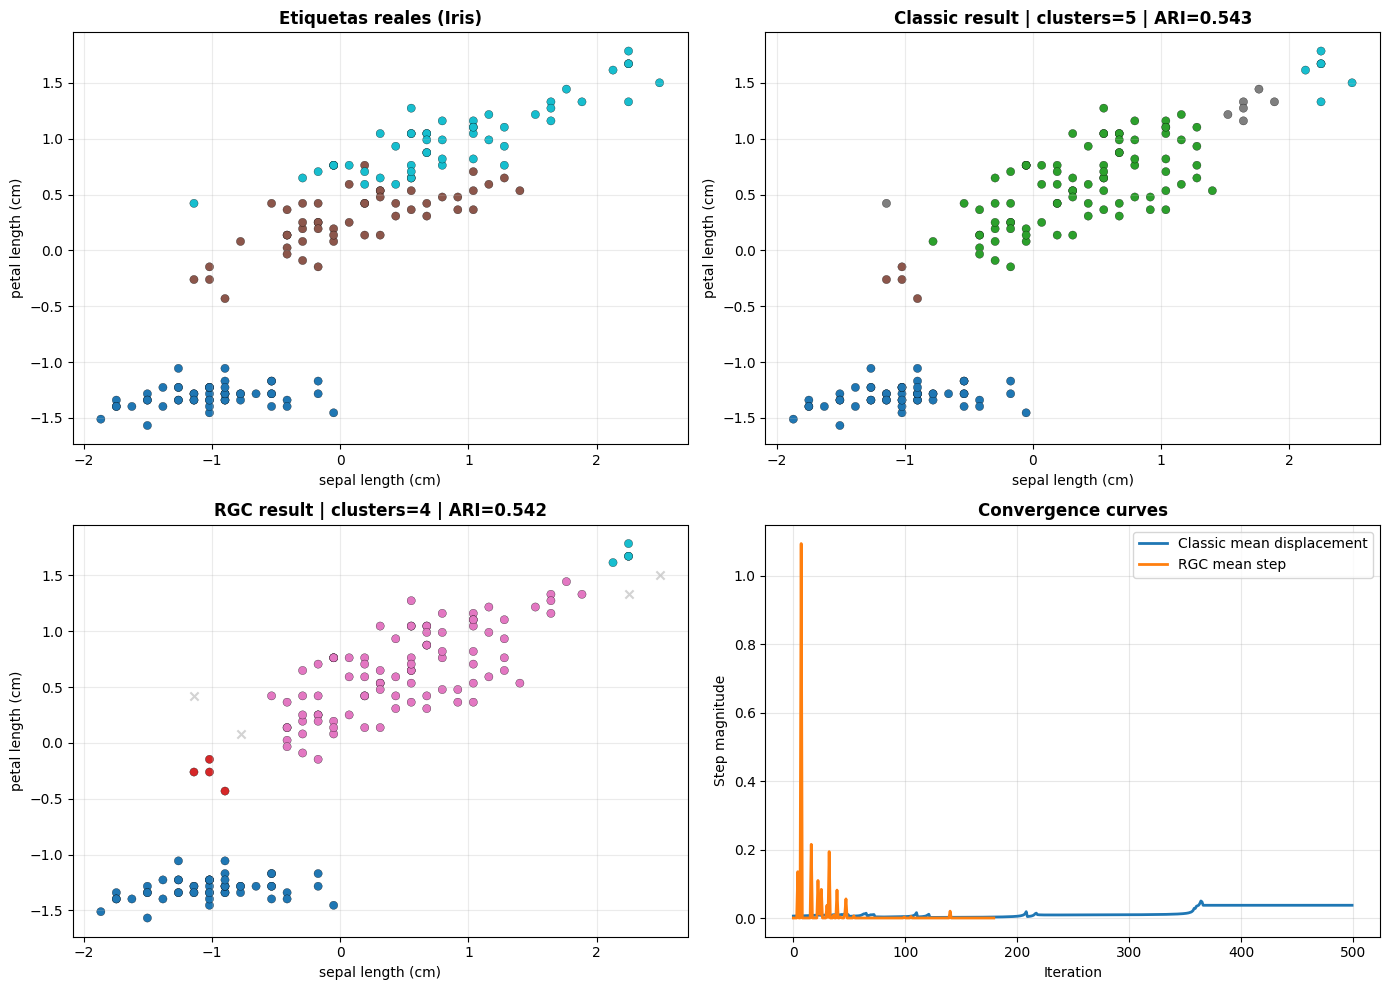

RGC info: {'d_hat': 0.17051228074080937, 'eps': 0.272819649185295, 'final_G': 1.0395662622314058e-05}


In [88]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=35, edgecolors="k", linewidths=0.2)
axes[0, 0].set_title("Etiquetas reales (Iris)", fontweight="bold")

axes[0, 1].scatter(X[:, 0], X[:, 1], c=classic.labels_, cmap="tab10", s=35, edgecolors="k", linewidths=0.2)
axes[0, 1].set_title(f"Classic result | clusters={classic.n_clusters_} | ARI={classic_metrics['ARI']:.3f}", fontweight="bold")

valid_rgc = rgc_labels >= 0
axes[1, 0].scatter(X[valid_rgc, 0], X[valid_rgc, 1], c=rgc_labels[valid_rgc], cmap="tab10", s=35, edgecolors="k", linewidths=0.2)
if (~valid_rgc).any():
    axes[1, 0].scatter(X[~valid_rgc, 0], X[~valid_rgc, 1], c="lightgray", s=35, marker="x", label="noise")
axes[1, 0].set_title(f"RGC result | clusters={rgc_metrics['n_clusters']} | ARI={rgc_metrics['ARI']:.3f}", fontweight="bold")

axes[1, 1].plot(classic.history_["displacement"], label="Classic mean displacement", linewidth=2)
axes[1, 1].plot(rgc_curve, label="RGC mean step", linewidth=2)
axes[1, 1].set_title("Convergence curves", fontweight="bold")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Step magnitude")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

for ax in [axes[0, 0], axes[0, 1], axes[1, 0]]:
    ax.set_xlabel(feature_cols[0])
    ax.set_ylabel(feature_cols[1])
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("RGC info:", rgc_info)

## 11. Síntesis de hallazgos

Las visualizaciones permiten contrastar: (i) etiquetas reales, (ii) partición clásica, (iii) partición RGC y (iv) convergencia.

La dinámica gravitacional reorganiza la nube de puntos hacia regiones con mayor cohesión interna y menor superposición entre clases.